<b><u>Car-Price-Prediction-Dashboard

<B>2.
Develop an interface to predict used car prices using features like year, fuel type, and mileage.

Task:

1.	Load and clean car dataset.
2.	Perform regression modeling.
3.	Visualize feature importance.
4.	Create user input interface.
5.	Display predicted price with charts.


<b><U>Train Regression Model

<u><B>importing required lybraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pickle


<b>creating dataset

In [2]:
import pandas as pd

data = {
    'Year': [2018, 2016, 2020, 2017, 2019, 2015, 2021, 2018, 2014, 2022],
    'Fuel_Type': ['Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol',
                  'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol'],
    'Mileage': [35000, 60000, 20000, 50000, 30000,
                70000, 15000, 45000, 80000, 10000],
    'Price': [500000, 400000, 800000, 450000, 650000,
              350000, 900000, 550000, 250000, 1000000]
}

df = pd.DataFrame(data)

df.to_csv('car_data.csv', index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Year Fuel_Type  Mileage   Price
0  2018    Petrol    35000  500000
1  2016    Diesel    60000  400000
2  2020    Petrol    20000  800000
3  2017    Diesel    50000  450000
4  2019    Petrol    30000  650000


In [3]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pickle.dump(model, open("model.pkl", "wb"))

print("Model Saved")

Model Saved


<b><u>Create Dashboard

<b><u>Create app.py

In [5]:
!pip install streamlit
import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open("model.pkl", "rb"))

st.title("Car Price Prediction Dashboard")

year = st.number_input("Year", 2000, 2025)
mileage = st.number_input("Mileage")
fuel = st.selectbox("Fuel Type", ["Petrol", "Diesel"])

fuel_diesel = 1 if fuel == "Diesel" else 0

input_data = pd.DataFrame({
    "Year":[year],
    "Mileage":[mileage],
    "Fuel_Type_Diesel":[fuel_diesel]
})

if st.button("Predict"):
    prediction = model.predict(input_data)
    st.success(f"Predicted Price: ₹{prediction[0]:,.0f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.3 MB/s eta 0:00:00


2026-06-04 10:05:54.027 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.369 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-04 10:05:54.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.377 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:05:54.378 Thread 'MainThread': mi

<u><b>Feature Importance Visualization

2026-06-04 10:06:31.697 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:06:31.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:06:31.982 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 10:06:31.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

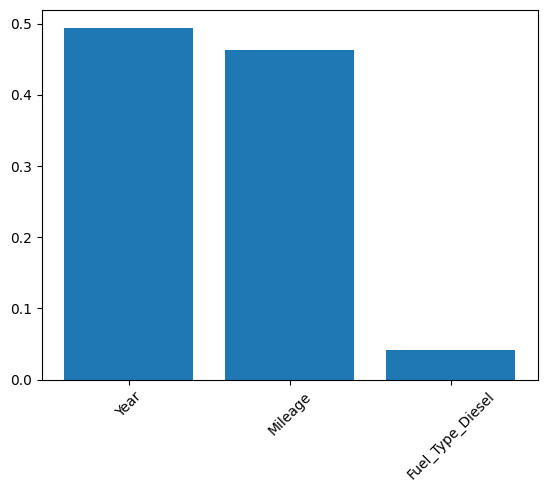

In [6]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = input_data.columns

fig, ax = plt.subplots()

ax.bar(features, importance)

plt.xticks(rotation=45)

st.pyplot(fig)